 # ShopSphere - Exploratory Data Analysis & Business Analysis



 This notebook performs:

 - Dataset overview

 - Data quality checks

 - Customer analysis

 - Order analysis

 - Revenue analysis

 - Product/category analysis

 - Customer segment analysis

 - Regional analysis

 - Discount analysis

 - Marketing analysis

 - Customer interaction analysis

 - Repeat customer analysis

 - Monthly and quarterly analysis

 - Business insights



 Revenue definition:

 Order-level revenue  -> calculated_order_value

 Product-level revenue -> item_revenue

 Profit -> profit

In [150]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully!")



Libraries imported successfully!


 ## 1. Load Cleaned Data

In [151]:
# ============================================================
# CELL 2: LOAD CLEANED DATA
# ============================================================

clean_data_path = (
    r"C:\Users\HP\Desktop\Project 1= ShopSphere"
    r"\shopsphere_dataset\shopsphere_dataset\clean_data"
)

customers = pd.read_csv(
    os.path.join(
        clean_data_path,
        "customers_clean.csv"
    )
)

products = pd.read_csv(
    os.path.join(
        clean_data_path,
        "products_clean.csv"
    )
)

orders = pd.read_csv(
    os.path.join(
        clean_data_path,
        "orders_clean.csv"
    )
)

order_items = pd.read_csv(
    os.path.join(
        clean_data_path,
        "order_items_clean.csv"
    )
)

customer_interactions = pd.read_csv(
    os.path.join(
        clean_data_path,
        "customer_interactions_clean.csv"
    )
)

marketing_campaigns = pd.read_csv(
    os.path.join(
        clean_data_path,
        "marketing_campaigns_clean.csv"
    )
)

print("All cleaned datasets loaded successfully!")



All cleaned datasets loaded successfully!


 ## 2. Convert Date Columns

In [152]:
# ============================================================
# CELL 3: DATE CONVERSION
# ============================================================

customers["date_of_birth"] = pd.to_datetime(
    customers["date_of_birth"],
    errors="coerce"
)

customers["signup_date"] = pd.to_datetime(
    customers["signup_date"],
    errors="coerce"
)

products["launch_date"] = pd.to_datetime(
    products["launch_date"],
    errors="coerce"
)

orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

customer_interactions[
    "interaction_datetime"
] = pd.to_datetime(
    customer_interactions[
        "interaction_datetime"
    ],
    errors="coerce"
)

marketing_campaigns[
    "campaign_date"
] = pd.to_datetime(
    marketing_campaigns["campaign_date"],
    errors="coerce"
)

print("Date columns converted successfully!")



Date columns converted successfully!


 ## 3. Dataset Overview

In [153]:
# ============================================================
# CELL 4: DATASET OVERVIEW
# ============================================================

datasets = {
    "Customers": customers,
    "Products": products,
    "Orders": orders,
    "Order Items": order_items,
    "Customer Interactions": customer_interactions,
    "Marketing Campaigns": marketing_campaigns
}

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

for name, df in datasets.items():

    print(
        f"{name:<25}"
        f" Rows: {df.shape[0]:>10,}"
        f" | Columns: {df.shape[1]}"
    )



DATASET OVERVIEW
Customers                 Rows:     30,000 | Columns: 15
Products                  Rows:      2,000 | Columns: 11
Orders                    Rows:    149,500 | Columns: 12
Order Items               Rows:    346,867 | Columns: 9
Customer Interactions     Rows:    200,000 | Columns: 9
Marketing Campaigns       Rows:     20,000 | Columns: 11


 ## 4. Basic Statistics

In [154]:
# ============================================================
# CELL 5: BASIC STATISTICS
# ============================================================

print("========== CUSTOMERS ==========")
display(customers.describe(include="all"))

print("\n========== PRODUCTS ==========")
display(products.describe(include="all"))

print("\n========== ORDERS ==========")
display(orders.describe(include="all"))

print("\n========== ORDER ITEMS ==========")
display(order_items.describe(include="all"))



========== CUSTOMERS ==========


C:\Users\HP\AppData\Local\Temp\ipykernel_157756\1098868414.py:6: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  display(customers.describe(include="all"))
C:\Users\HP\AppData\Local\Temp\ipykernel_157756\1098868414.py:6: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  display(customers.describe(include="all"))


,customer_id,first_name,last_name,gender,date_of_birth,city,state,region,pincode,signup_date,customer_segment,income,acquisition_channel,customer_status,email
count,30000,30000,30000,30000,29302,30000,30000,30000,"30,000.00",30000,30000,"30,000.00",30000,30000,30000
unique,30000,30,20,3,13836,53,18,8,NaN,700,6,NaN,7,2,30000
top,C100001,Aditya,Iyer,Female,1971-06-25 00:00:00,Mumbai,Maharashtra,West,NaN,2024-05-08 00:00:00,Occasional,NaN,Organic,Active,user1@example.com
freq,1,1047,1560,14645,10,1503,5885,10143,NaN,68,12083,NaN,7386,25200,1
first,NaN,NaN,NaN,NaN,1960-01-01 00:00:00,NaN,NaN,NaN,NaN,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
last,NaN,NaN,NaN,NaN,2005-12-31 00:00:00,NaN,NaN,NaN,NaN,2025-11-30 00:00:00,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"551,191.95",NaN,NaN,"130,594.26",NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"259,582.37",NaN,NaN,"898,802.78",NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"100,015.00",NaN,NaN,"12,000.00",NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"326,432.25",NaN,NaN,"56,521.74",NaN,NaN,NaN



========== PRODUCTS ==========


C:\Users\HP\AppData\Local\Temp\ipykernel_157756\1098868414.py:9: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  display(products.describe(include="all"))


...


========== ORDERS ==========


C:\Users\HP\AppData\Local\Temp\ipykernel_157756\1098868414.py:12: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  display(orders.describe(include="all"))


,order_id,customer_id,order_date,order_status,payment_method,shipping_city,shipping_region,discount_amount,shipping_fee,order_value,calculated_order_value,order_date_missing
count,149500,149500,149000,149500,149500,149500,149500,"149,500.00","149,500.00","148,500.00","149,209.00",149500
unique,149500,28772,138760,4,6,53,8,NaN,NaN,NaN,NaN,2
top,O100001,C108398,2024-05-13 21:42:00,Delivered,UPI,Mumbai,West,NaN,NaN,NaN,NaN,False
freq,1,24,5,124054,47701,7678,50810,NaN,NaN,NaN,NaN,149000
first,NaN,NaN,2024-01-01 00:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,NaN,NaN,2025-12-30 23:56:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,239.80,70.27,"2,650.53","52,973.37",NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,169.66,29.72,"2,986.30","112,985.99",NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.36,0.00,"-28,966.24",4.41,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.18,49.82,960.25,"4,777.21",NaN



========== ORDER ITEMS ==========


,order_item_id,order_id,product_id,quantity,unit_price,discount_percent,item_revenue,item_cost,profit
count,346867,346867,346867,"346,867.00","346,867.00","346,867.00","346,867.00","346,867.00","346,867.00"
unique,346867,149209,2000,NaN,NaN,NaN,NaN,NaN,NaN
top,OI1000001,O156141,P10618,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,6,274,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.75,"14,214.40",8.26,"22,756.91","15,257.92","7,498.98"
std,NaN,NaN,NaN,1.01,"37,163.69",5.53,"71,355.35","32,457.23","59,025.34"
min,NaN,NaN,NaN,1.00,57.91,0.00,0.00,"-332,636.60","-113,006.50"
25%,NaN,NaN,NaN,1.00,"1,056.34",3.96,"1,374.82","1,095.16",159.31
50%,NaN,NaN,NaN,1.00,"2,887.61",8.00,"4,328.60","3,378.46",608.32
75%,NaN,NaN,NaN,2.00,"15,769.70",12.05,"20,398.49","16,046.16","3,137.01"


 ## 5. Missing Value Summary

In [155]:
# ============================================================
# CELL 6: MISSING VALUE SUMMARY
# ============================================================

print("=" * 70)
print("MISSING VALUE SUMMARY")
print("=" * 70)

for name, df in datasets.items():

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    print(f"\n{name}")

    if len(missing) == 0:
        print("No missing values.")
    else:
        display(missing)



MISSING VALUE SUMMARY

Customers


date_of_birth    698
dtype: int64


Products
No missing values.

Orders


order_date                 500
order_value               1000
calculated_order_value     291
dtype: int64


Order Items
No missing values.

Customer Interactions
No missing values.

Marketing Campaigns
No missing values.


 ## 6. Customer Segment Analysis

Occasional    12083
Regular       10342
Premium        7325
occasional      119
regular          79
premium          52
Name: customer_segment, dtype: int64

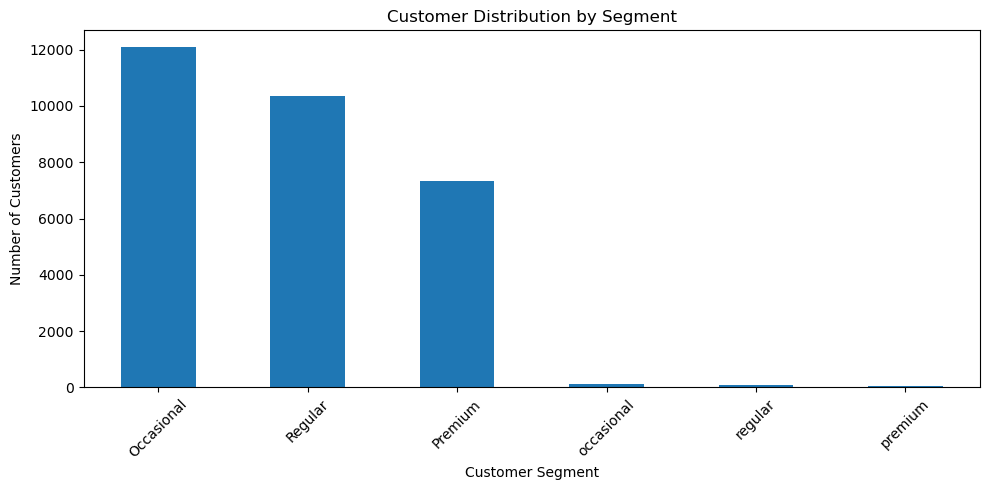

In [156]:
# ============================================================
# CELL 7: CUSTOMER SEGMENT DISTRIBUTION
# ============================================================

segment_counts = (
    customers["customer_segment"]
    .value_counts()
)

display(segment_counts)

plt.figure(figsize=(10, 5))

segment_counts.plot(
    kind="bar"
)

plt.title(
    "Customer Distribution by Segment"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



 ## 7. Customer Status

Active      25200
Inactive     4800
Name: customer_status, dtype: int64

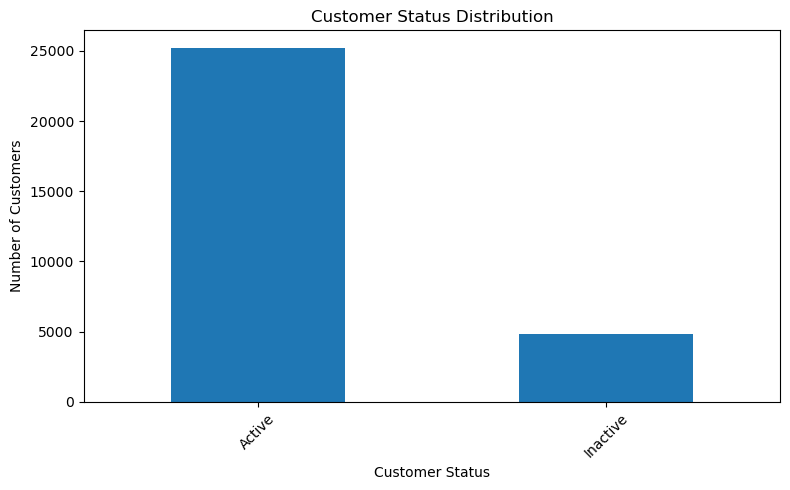

In [157]:
# ============================================================
# CELL 8: CUSTOMER STATUS
# ============================================================

status_counts = (
    customers["customer_status"]
    .value_counts()
)

display(status_counts)

plt.figure(figsize=(8, 5))

status_counts.plot(
    kind="bar"
)

plt.title(
    "Customer Status Distribution"
)

plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



 ## 8. Customer Acquisition Channel

Organic         7386
Search Ads      5860
Social Media    5180
Affiliate       3889
Email           3644
Referral        3591
Unknown          450
Name: acquisition_channel, dtype: int64

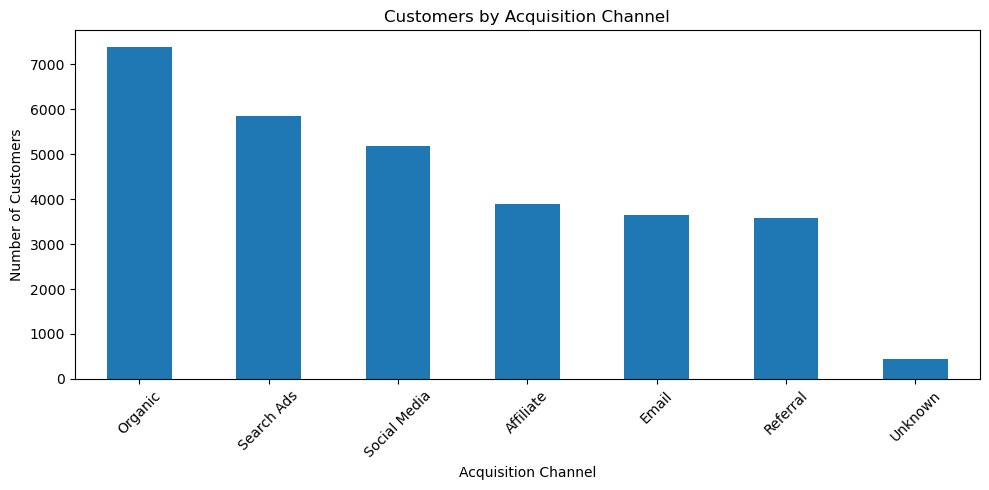

In [158]:
# ============================================================
# CELL 9: CUSTOMER ACQUISITION CHANNEL
# ============================================================

acquisition_counts = (
    customers["acquisition_channel"]
    .value_counts()
)

display(acquisition_counts)

plt.figure(figsize=(10, 5))

acquisition_counts.plot(
    kind="bar"
)

plt.title(
    "Customers by Acquisition Channel"
)

plt.xlabel("Acquisition Channel")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



 ## 9. Order Status

Delivered    124054
Cancelled     10622
Returned       8957
Pending        5867
Name: order_status, dtype: int64

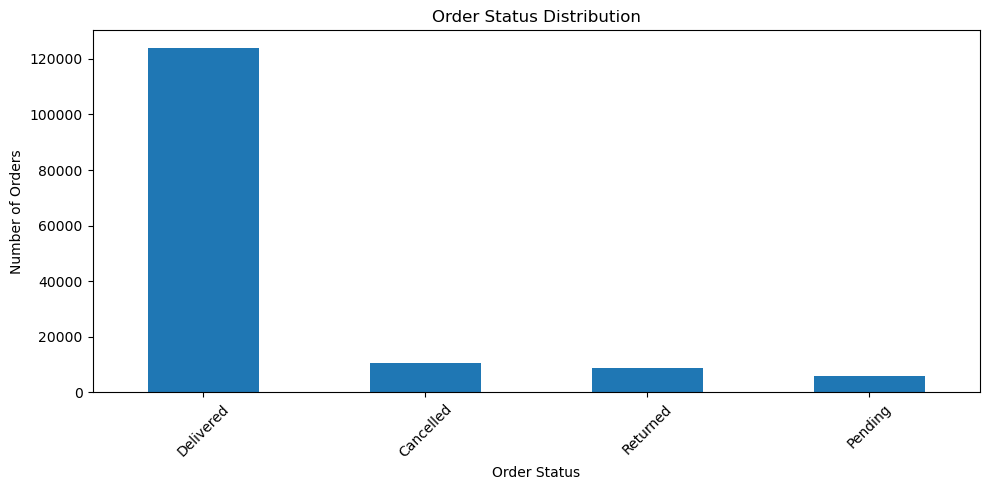

In [159]:
# ============================================================
# CELL 10: ORDER STATUS
# ============================================================

order_status_counts = (
    orders["order_status"]
    .value_counts()
)

display(order_status_counts)

plt.figure(figsize=(10, 5))

order_status_counts.plot(
    kind="bar"
)

plt.title(
    "Order Status Distribution"
)

plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



 ## 10. Payment Method

UPI                 47701
Credit Card         37268
Debit Card          23890
Net Banking         14919
Wallet              13685
Cash on Delivery    12037
Name: payment_method, dtype: int64

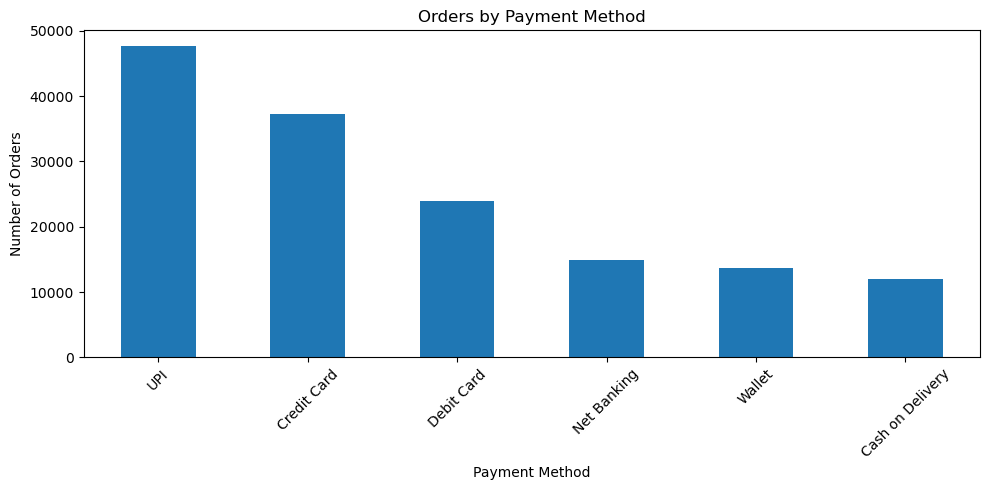

In [160]:
# ============================================================
# CELL 11: PAYMENT METHOD
# ============================================================

payment_counts = (
    orders["payment_method"]
    .value_counts()
)

display(payment_counts)

plt.figure(figsize=(10, 5))

payment_counts.plot(
    kind="bar"
)

plt.title(
    "Orders by Payment Method"
)

plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



 # CORE BUSINESS KPIs

In [161]:
# ============================================================
# CELL 12: BUSINESS KPIs
# ============================================================

# Only orders with valid calculated revenue
valid_revenue_orders = orders[
    orders["calculated_order_value"].notna()
].copy()

# Total validated revenue
total_revenue = (
    valid_revenue_orders[
        "calculated_order_value"
    ].sum()
)

# Total orders
total_orders = (
    orders["order_id"].nunique()
)

# Total customers
total_customers = (
    customers["customer_id"].nunique()
)

# Average Order Value
average_order_value = (
    valid_revenue_orders[
        "calculated_order_value"
    ].mean()
)

# Total product-level revenue
total_item_revenue = (
    order_items["item_revenue"].sum()
)

# Total profit
total_profit = (
    order_items["profit"].sum()
)

# Profit margin
profit_margin = (
    total_profit
    / total_item_revenue
    * 100
    if total_item_revenue != 0
    else 0
)

# Cancelled orders
cancelled_orders = orders[
    orders["order_status"]
    .astype(str)
    .str.lower()
    .eq("cancelled")
]["order_id"].nunique()

# Cancellation rate
cancellation_rate = (
    cancelled_orders
    / total_orders
    * 100
    if total_orders != 0
    else 0
)

kpi_summary = pd.DataFrame({

    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Total Item Revenue",
        "Total Profit",
        "Profit Margin %",
        "Cancelled Orders",
        "Cancellation Rate %",
        "Orders with Valid Revenue"
    ],

    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        average_order_value,
        total_item_revenue,
        total_profit,
        profit_margin,
        cancelled_orders,
        cancellation_rate,
        len(valid_revenue_orders)
    ]
})

display(kpi_summary)



,KPI,Value
0,Total Revenue,"7,904,103,669.66"
1,Total Orders,"149,500.00"
2,Total Customers,"30,000.00"
3,Average Order Value,"52,973.37"
4,Total Item Revenue,"7,893,619,492.42"
5,Total Profit,"2,601,149,330.28"
6,Profit Margin %,32.95
7,Cancelled Orders,"10,622.00"
8,Cancellation Rate %,7.11
9,Orders with Valid Revenue,"149,209.00"


 ## 11. Time Features

In [162]:
# ============================================================
# CELL 13: TIME FEATURES
# ============================================================

orders["year"] = (
    orders["order_date"].dt.year
)

orders["month"] = (
    orders["order_date"].dt.month
)

orders["month_name"] = (
    orders["order_date"].dt.month_name()
)

orders["year_month"] = (
    orders["order_date"].dt.to_period("M")
)

orders["quarter"] = (
    orders["order_date"].dt.quarter
)

orders["quarter_label"] = (
    orders["year"].astype("Int64").astype(str)
    + " Q"
    + orders["quarter"].astype("Int64").astype(str)
)

print("Time features created successfully!")



Time features created successfully!


 # MONTHLY REVENUE ANALYSIS

In [163]:
# ============================================================
# CELL 14: MONTHLY REVENUE
# ============================================================

monthly_revenue = (
    valid_revenue_orders
    .dropna(subset=["order_date"])
    .groupby(
        valid_revenue_orders[
            "order_date"
        ].dropna().dt.to_period("M")
    )["calculated_order_value"]
    .agg(
        revenue="sum",
        orders="count",
        average_order_value="mean"
    )
    .reset_index()
)

monthly_revenue.rename(
    columns={
        "order_date": "year_month"
    },
    inplace=True
)

monthly_revenue["year_month"] = (
    monthly_revenue["year_month"]
    .astype(str)
)

display(monthly_revenue)



,year_month,revenue,orders,average_order_value
0,2024-01,"318,339,227.00",6272,"50,755.62"
1,2024-02,"314,439,652.16",6040,"52,059.55"
2,2024-03,"345,161,425.99",6342,"54,424.70"
3,2024-04,"319,067,733.47",6106,"52,254.79"
4,2024-05,"333,083,135.94",6280,"53,038.72"
5,2024-06,"327,708,115.47",6155,"53,242.59"
6,2024-07,"329,606,381.63",6381,"51,654.35"
7,2024-08,"332,071,106.37",6348,"52,311.14"
8,2024-09,"328,313,296.68",6037,"54,383.52"
9,2024-10,"331,383,468.26",6252,"53,004.39"


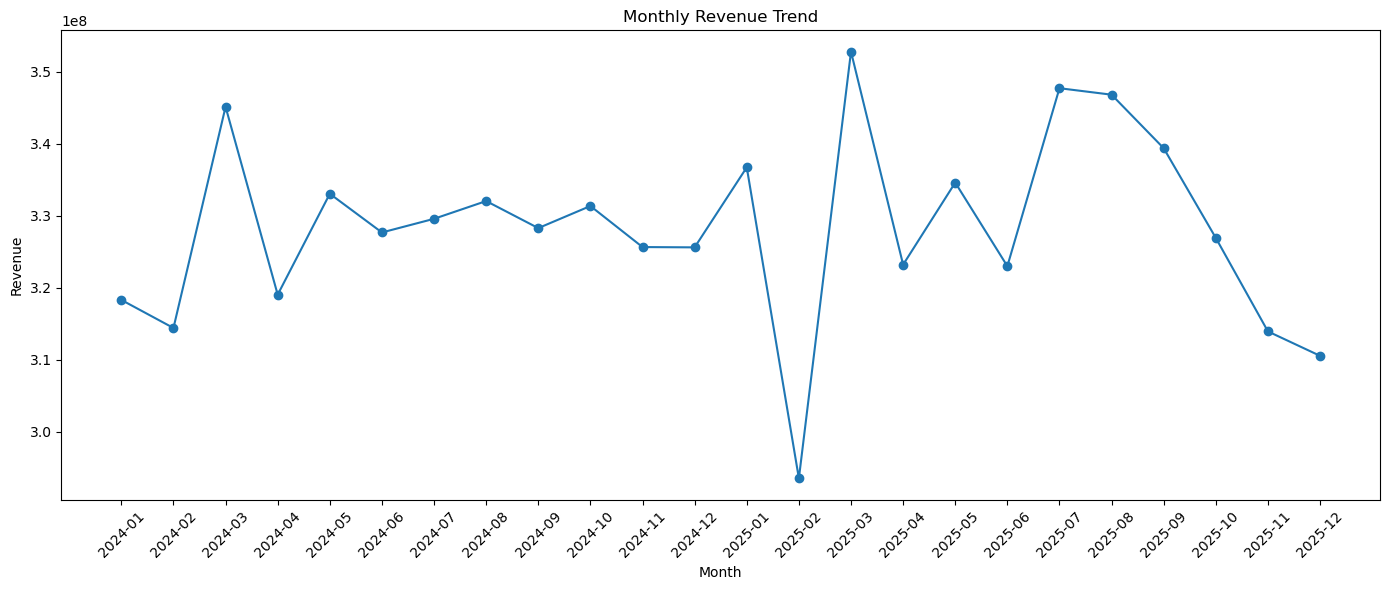

In [164]:
# ============================================================
# CELL 15: MONTHLY REVENUE TREND
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["year_month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()



 # QUARTERLY ANALYSIS

In [165]:
# ============================================================
# CREATE TIME FEATURES FOR VALID REVENUE ORDERS
# ============================================================

valid_revenue_orders = orders[
    orders["calculated_order_value"].notna()
].copy()

valid_revenue_orders["order_date"] = pd.to_datetime(
    valid_revenue_orders["order_date"],
    errors="coerce"
)

valid_revenue_orders["year"] = (
    valid_revenue_orders["order_date"].dt.year
)

valid_revenue_orders["quarter"] = (
    valid_revenue_orders["order_date"].dt.quarter
)

valid_revenue_orders["month"] = (
    valid_revenue_orders["order_date"].dt.month
)

valid_revenue_orders["month_name"] = (
    valid_revenue_orders["order_date"].dt.month_name()
)

print("Time features created successfully!")

display(
    valid_revenue_orders[
        [
            "order_id",
            "order_date",
            "year",
            "quarter",
            "calculated_order_value"
        ]
    ].head()
)

Time features created successfully!


,order_id,order_date,year,quarter,calculated_order_value
0,O100001,2024-11-05 22:30:00,"2,024.00",4.00,"2,265.39"
1,O100002,2025-01-01 02:58:00,"2,025.00",1.00,"3,461.39"
2,O100003,2024-11-13 15:44:00,"2,024.00",4.00,"43,003.03"
3,O100004,2025-11-06 17:55:00,"2,025.00",4.00,"5,108.04"
4,O100005,2024-11-11 10:40:00,"2,024.00",4.00,"2,744.40"


In [166]:
# ============================================================
# CELL 16: QUARTERLY REVENUE
# ============================================================

quarterly_revenue = (
    valid_revenue_orders
    .dropna(subset=["order_date"])
    .groupby(
        [
            "year",
            "quarter"
        ]
    )
    .agg(
        revenue=(
            "calculated_order_value",
            "sum"
        ),
        orders=(
            "order_id",
            "nunique"
        ),
        average_order_value=(
            "calculated_order_value",
            "mean"
        )
    )
    .reset_index()
)

quarterly_revenue[
    "quarter_label"
] = (
    quarterly_revenue["year"].astype(int).astype(str)
    + " Q"
    + quarterly_revenue["quarter"].astype(int).astype(str)
)

quarterly_revenue = (
    quarterly_revenue
    .sort_values(
        ["year", "quarter"]
    )
)

quarterly_revenue[
    "revenue_growth_pct"
] = (
    quarterly_revenue["revenue"]
    .pct_change()
    * 100
)

display(quarterly_revenue)



,year,quarter,revenue,orders,average_order_value,quarter_label,revenue_growth_pct
0,"2,024.00",1.00,"977,940,305.15",18654,"52,425.23",2024 Q1,NaN
1,"2,024.00",2.00,"979,858,984.88",18541,"52,848.23",2024 Q2,0.20
2,"2,024.00",3.00,"989,990,784.67",18766,"52,754.49",2024 Q3,1.03
3,"2,024.00",4.00,"982,702,337.62",18772,"52,349.37",2024 Q4,-0.74
4,"2,025.00",1.00,"983,123,751.16",18454,"53,274.29",2025 Q1,0.04
5,"2,025.00",2.00,"980,894,302.70",18375,"53,382.00",2025 Q2,-0.23
6,"2,025.00",3.00,"1,033,995,884.05",18750,"55,146.45",2025 Q3,5.41
7,"2,025.00",4.00,"951,483,060.86",18399,"51,713.85",2025 Q4,-7.98


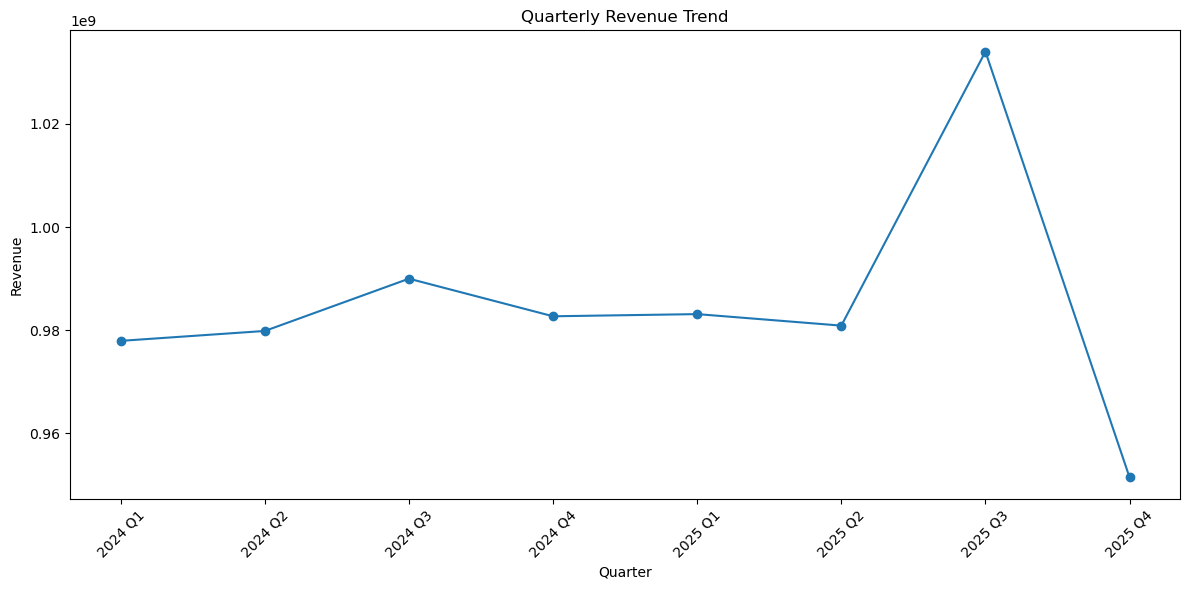

In [167]:
# ============================================================
# CELL 17: QUARTERLY REVENUE CHART
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_revenue["quarter_label"],
    quarterly_revenue["revenue"],
    marker="o"
)

plt.title(
    "Quarterly Revenue Trend"
)

plt.xlabel("Quarter")
plt.ylabel("Revenue")

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()



 # Q3 2025 ANALYSIS

In [168]:
# ============================================================
# CELL 18: Q3 2025
# ============================================================

q3_2025 = valid_revenue_orders[
    (valid_revenue_orders["year"] == 2025)
    &
    (valid_revenue_orders["quarter"] == 3)
].copy()

print(
    "Q3 2025 Orders:",
    len(q3_2025)
)

print(
    "Q3 2025 Revenue:",
    f"₹{q3_2025['calculated_order_value'].sum():,.2f}"
)

print(
    "Q3 2025 AOV:",
    f"₹{q3_2025['calculated_order_value'].mean():,.2f}"
)



Q3 2025 Orders: 18750
Q3 2025 Revenue: ₹1,033,995,884.05
Q3 2025 AOV: ₹55,146.45


In [169]:
# ============================================================
# CELL 19: Q3 MONTHLY REVENUE
# ============================================================

q3_monthly = (
    q3_2025
    .groupby("month_name")
    .agg(
        revenue=(
            "calculated_order_value",
            "sum"
        ),
        orders=(
            "order_id",
            "nunique"
        ),
        average_order_value=(
            "calculated_order_value",
            "mean"
        )
    )
    .reset_index()
)

display(q3_monthly)



,month_name,revenue,orders,average_order_value
0,August,"346,844,369.56",6277,"55,256.39"
1,July,"347,744,032.10",6267,"55,488.12"
2,September,"339,407,482.39",6206,"54,690.22"


 # PRODUCT & CATEGORY ANALYSIS

In [170]:
# ============================================================
# CELL 20: REVENUE BY PRODUCT CATEGORY
# ============================================================

category_analysis = (
    order_items
    .merge(
        products[
            [
                "product_id",
                "category",
                "subcategory",
                "brand"
            ]
        ],
        on="product_id",
        how="left"
    )
    .groupby("category")
    .agg(
        revenue=(
            "item_revenue",
            "sum"
        ),
        profit=(
            "profit",
            "sum"
        ),
        units_sold=(
            "quantity",
            "sum"
        ),
        orders=(
            "order_id",
            "nunique"
        )
    )
    .reset_index()
)

category_analysis[
    "profit_margin"
] = (
    category_analysis["profit"]
    / category_analysis["revenue"]
    * 100
)

category_analysis = (
    category_analysis
    .sort_values(
        "revenue",
        ascending=False
    )
)

display(category_analysis)



,category,revenue,profit,units_sold,orders,profit_margin
2,Electronics,"6,711,804,098.99","2,186,694,836.69",203666,83816,32.58
4,Home,"537,719,638.69","180,182,488.00",115237,54178,33.51
6,Unknown,"204,884,359.76","40,769,203.06",11189,6279,19.90
3,Fashion,"178,125,333.48","66,071,874.87",115968,54550,37.09
0,Beauty,"123,921,587.63","70,685,104.87",58722,30430,57.04
5,Sports,"92,992,632.38","28,105,796.14",49541,26035,30.22
1,Books,"44,171,841.49","28,640,026.65",52721,27535,64.84


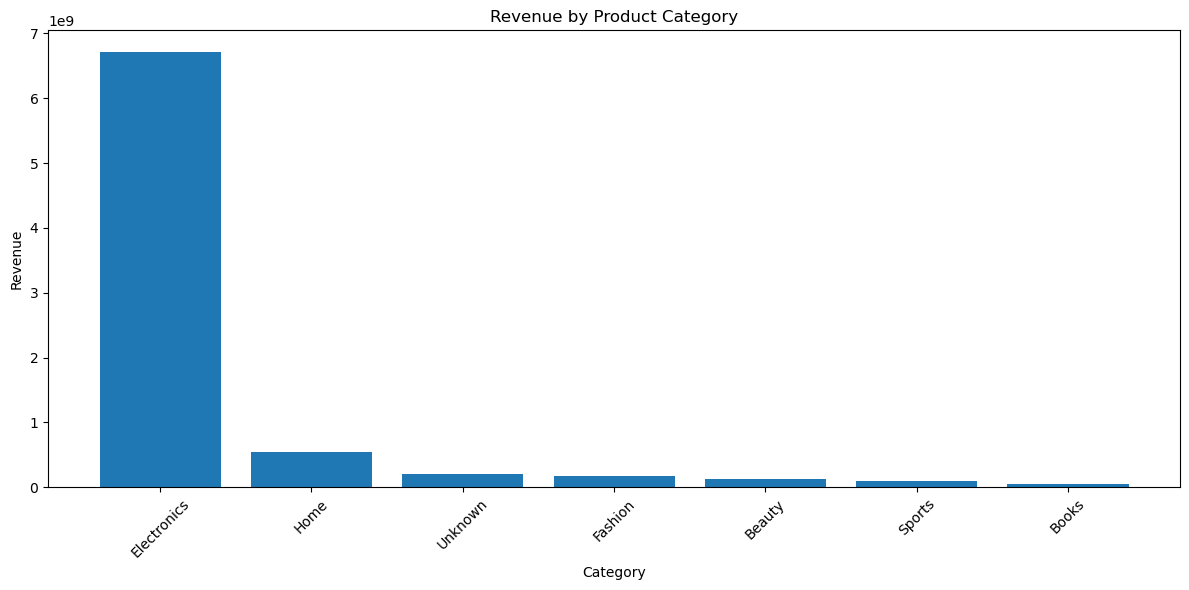

In [171]:
# ============================================================
# CELL 21: CATEGORY REVENUE CHART
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    category_analysis["category"],
    category_analysis["revenue"]
)

plt.title(
    "Revenue by Product Category"
)

plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()



In [172]:
# ============================================================
# CELL 22: TOP PRODUCTS
# ============================================================

product_analysis = (
    order_items
    .merge(
        products[
            [
                "product_id",
                "product_name",
                "category",
                "brand"
            ]
        ],
        on="product_id",
        how="left"
    )
    .groupby(
        [
            "product_id",
            "product_name",
            "category",
            "brand"
        ]
    )
    .agg(
        revenue=(
            "item_revenue",
            "sum"
        ),
        profit=(
            "profit",
            "sum"
        ),
        units_sold=(
            "quantity",
            "sum"
        ),
        orders=(
            "order_id",
            "nunique"
        )
    )
    .reset_index()
)

product_analysis = (
    product_analysis
    .sort_values(
        "revenue",
        ascending=False
    )
)

print("TOP 20 PRODUCTS BY REVENUE")

display(
    product_analysis.head(20)
)



TOP 20 PRODUCTS BY REVENUE


,product_id,product_name,category,brand,revenue,profit,units_sold,orders
768,P10769,Orbit Electronics Accessories 769,Electronics,TechPro,"234,297,040.00","222,659,632.48",368,208
1634,P11635,Orbit Electronics Laptops 1635,Electronics,Evergreen,"214,809,455.07","203,422,797.06",399,226
1477,P11478,StyleCraft Electronics Headphones 1478,Electronics,Evergreen,"182,238,221.66","171,229,508.36",390,211
1350,P11351,Apex Electronics Accessories 1351,Electronics,Nova,"159,134,646.72","151,210,551.04",421,234
326,P10327,VivoHome Electronics Smartphones 327,Electronics,Nova,"124,108,925.82","116,469,853.50",352,194
1513,P11514,TechPro Electronics Accessories 1514,Electronics,Evergreen,"96,897,044.90","96,878,744.90",366,212
1246,P11247,Evergreen Electronics Accessories 1247,Electronics,Orbit,"72,298,495.08","67,809,465.74",359,211
1598,P11599,Orbit Electronics Laptops 1599,Electronics,Apex,"66,595,117.58","13,187,829.02",372,212
1493,P11494,UrbanX Electronics Headphones 1494,Electronics,StyleCraft,"65,796,415.73","10,372,573.09",424,233
1140,P11141,VivoHome Electronics Smartwatches 1141,Electronics,Orbit,"65,449,192.02","61,234,194.99",331,203


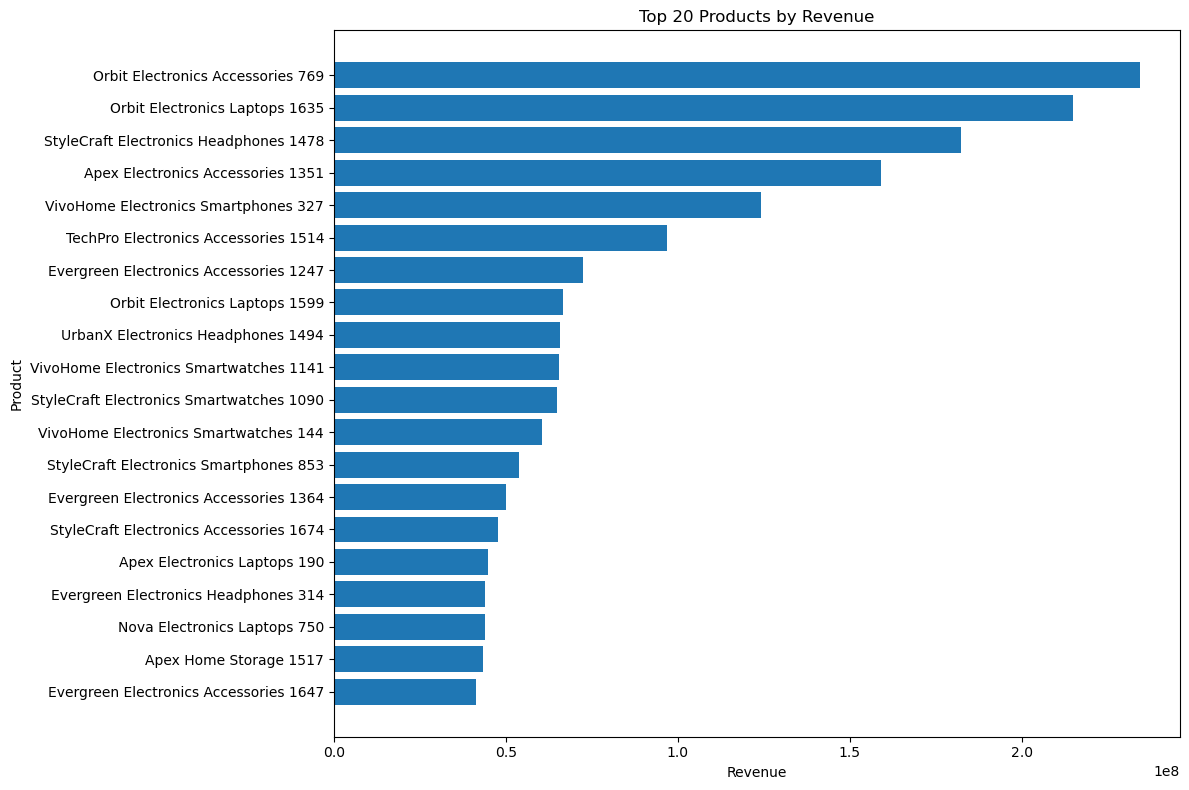

In [173]:
# ============================================================
# CELL 23: TOP 20 PRODUCTS CHART
# ============================================================

top_products = (
    product_analysis
    .head(20)
    .sort_values(
        "revenue"
    )
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_products["product_name"],
    top_products["revenue"]
)

plt.title(
    "Top 20 Products by Revenue"
)

plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()



 # CUSTOMER ANALYSIS

In [174]:
# ============================================================
# CELL 24: CUSTOMER VALUE ANALYSIS
# ============================================================

customer_revenue = (
    valid_revenue_orders
    .groupby("customer_id")
    .agg(
        total_revenue=(
            "calculated_order_value",
            "sum"
        ),
        total_orders=(
            "order_id",
            "nunique"
        ),
        average_order_value=(
            "calculated_order_value",
            "mean"
        )
    )
    .reset_index()
)

customer_revenue = (
    customer_revenue
    .merge(
        customers[
            [
                "customer_id",
                "customer_segment",
                "customer_status",
                "acquisition_channel",
                "region"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

customer_revenue = (
    customer_revenue
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

print("TOP 20 CUSTOMERS BY REVENUE")

display(
    customer_revenue.head(20)
)



TOP 20 CUSTOMERS BY REVENUE


,customer_id,total_revenue,total_orders,average_order_value,customer_segment,customer_status,acquisition_channel,region
18740,C119522,"4,057,778.60",11,"368,888.96",Regular,Active,Organic,East
5334,C105559,"3,933,827.22",13,"302,602.09",Premium,Active,Social Media,South
6393,C106663,"3,855,858.54",8,"481,982.32",Regular,Active,Social Media,West
2939,C103063,"3,606,794.18",11,"327,890.38",Premium,Active,Search Ads,West
24172,C125194,"3,545,478.49",16,"221,592.41",Premium,Active,Organic,South
26318,C127432,"3,542,580.51",9,"393,620.06",Regular,Active,Referral,North
25962,C127064,"3,473,391.90",4,"868,347.97",Premium,Active,Email,East
10752,C111203,"3,421,416.89",8,"427,677.11",Regular,Active,Organic,South
7583,C107898,"3,382,654.78",10,"338,265.48",Regular,Active,Social Media,West
69,C100075,"3,315,938.63",5,"663,187.73",Premium,Inactive,Search Ads,West


In [175]:
# ============================================================
# CELL 25: REVENUE BY CUSTOMER SEGMENT
# ============================================================

segment_revenue = (
    customer_revenue
    .groupby("customer_segment")
    .agg(
        revenue=(
            "total_revenue",
            "sum"
        ),
        customers=(
            "customer_id",
            "nunique"
        ),
        orders=(
            "total_orders",
            "sum"
        )
    )
    .reset_index()
)

segment_revenue[
    "revenue_per_customer"
] = (
    segment_revenue["revenue"]
    / segment_revenue["customers"]
)

segment_revenue = (
    segment_revenue
    .sort_values(
        "revenue",
        ascending=False
    )
)

display(segment_revenue)



,customer_segment,revenue,customers,orders,revenue_per_customer
1,Premium,"3,173,550,166.90",7298,60567,"434,852.04"
2,Regular,"2,805,989,364.30",10100,52391,"277,820.73"
0,Occasional,"1,883,416,833.81",11137,35479,"169,113.48"
3,occasional,"19,016,312.77",113,365,"168,285.95"
5,regular,"11,511,971.97",74,252,"155,567.19"
4,premium,"10,619,019.91",45,155,"235,978.22"


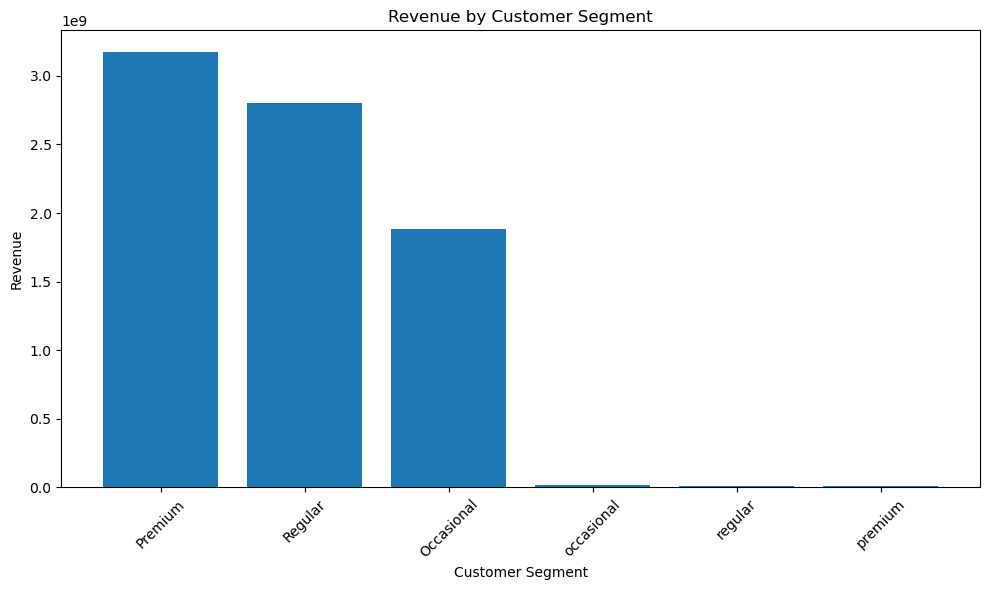

In [176]:
# ============================================================
# CELL 26: SEGMENT REVENUE CHART
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    segment_revenue["customer_segment"],
    segment_revenue["revenue"]
)

plt.title(
    "Revenue by Customer Segment"
)

plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()



 # REGION ANALYSIS

In [177]:
# ============================================================
# CELL 27: REGION PERFORMANCE
# ============================================================

region_analysis = (
    valid_revenue_orders
    .groupby("shipping_region")
    .agg(
        revenue=(
            "calculated_order_value",
            "sum"
        ),
        orders=(
            "order_id",
            "nunique"
        ),
        average_order_value=(
            "calculated_order_value",
            "mean"
        )
    )
    .reset_index()
)

region_analysis = (
    region_analysis
    .sort_values(
        "revenue",
        ascending=False
    )
)

display(region_analysis)



,shipping_region,revenue,orders,average_order_value
7,West,"2,684,049,942.89",50721,"52,917.92"
3,North,"1,932,974,353.83",36304,"53,244.12"
5,South,"1,912,461,541.48",36105,"52,969.44"
1,East,"1,324,415,686.37",25069,"52,830.81"
6,WEST,"20,232,843.46",372,"54,389.36"
4,SOUTH,"15,616,744.34",310,"50,376.59"
2,NORTH,"7,411,151.59",200,"37,055.76"
0,EAST,"6,941,405.68",128,"54,229.73"


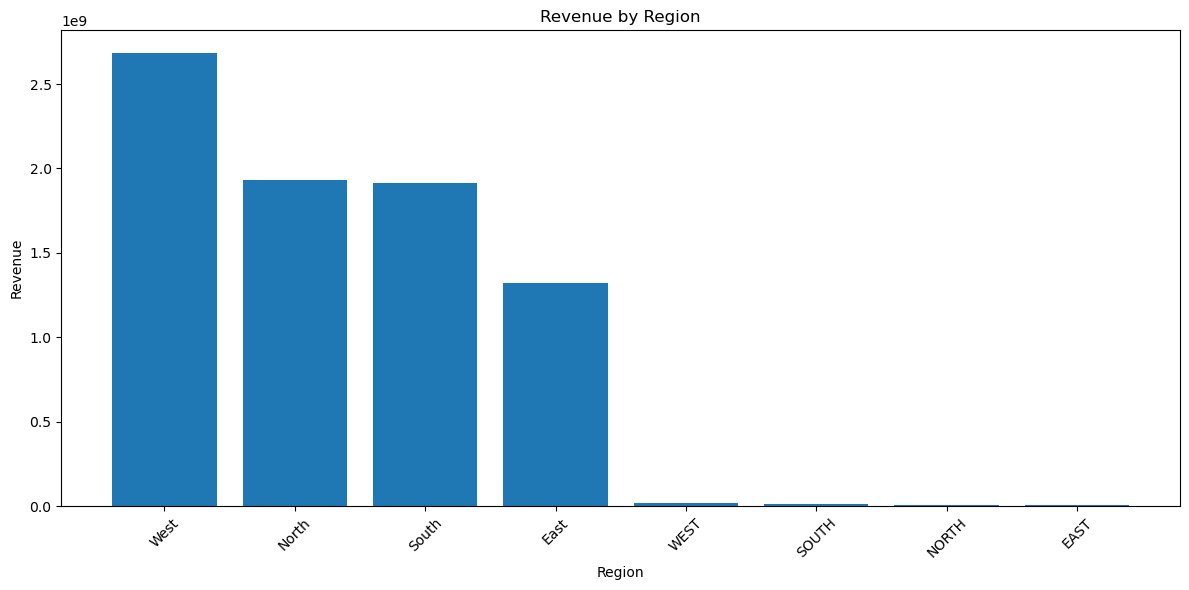

In [178]:
# ============================================================
# CELL 28: REGION REVENUE CHART
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    region_analysis["shipping_region"],
    region_analysis["revenue"]
)

plt.title(
    "Revenue by Region"
)

plt.xlabel("Region")
plt.ylabel("Revenue")

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()



 # DISCOUNT ANALYSIS

In [179]:
# ============================================================
# CELL 29: DISCOUNT ANALYSIS
# ============================================================

discount_analysis = (
    valid_revenue_orders
    .copy()
)

discount_analysis[
    "discount_rate"
] = (
    discount_analysis["discount_amount"]
    /
    (
        discount_analysis[
            "calculated_order_value"
        ]
        +
        discount_analysis[
            "discount_amount"
        ]
    )
    * 100
)

discount_analysis[
    "discount_rate"
] = (
    discount_analysis[
        "discount_rate"
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

discount_analysis = (
    discount_analysis
    .dropna(
        subset=["discount_rate"]
    )
)

print("Discount statistics:")

display(
    discount_analysis[
        [
            "calculated_order_value",
            "discount_amount",
            "discount_rate"
        ]
    ].describe()
)



Discount statistics:


,calculated_order_value,discount_amount,discount_rate
count,"149,209.00","149,209.00","149,209.00"
mean,"52,973.37",239.78,4.35
std,"112,985.99",169.66,8.75
min,4.41,0.36,0.00
25%,"4,777.21",115.17,0.29
50%,"21,126.85",201.06,0.93
75%,"60,201.51",322.57,3.92
max,"3,408,285.82","1,948.70",99.04


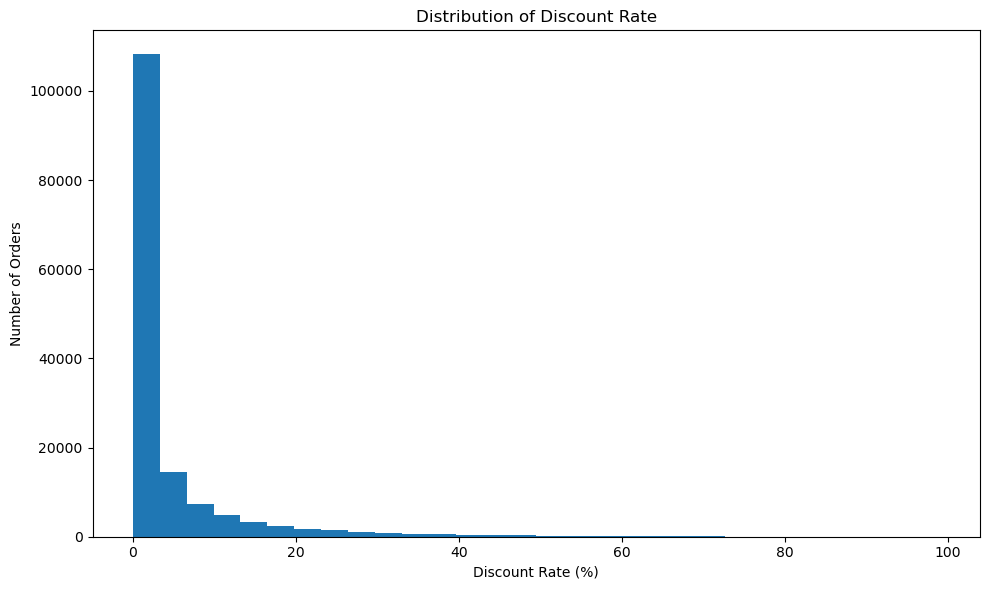

In [180]:
# ============================================================
# CELL 30: DISCOUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    discount_analysis["discount_rate"],
    bins=30
)

plt.title(
    "Distribution of Discount Rate"
)

plt.xlabel("Discount Rate (%)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()



 # MARKETING CAMPAIGN ANALYSIS

In [181]:
# ============================================================
# CELL 31: MARKETING CAMPAIGN PERFORMANCE
# ============================================================

campaign_analysis = (
    marketing_campaigns
    .groupby(
        [
            "campaign_id",
            "campaign_name",
            "campaign_channel"
        ]
    )
    .agg(
        impressions=(
            "impression",
            "sum"
        ),
        clicks=(
            "clicked",
            "sum"
        ),
        conversions=(
            "converted",
            "sum"
        ),
        campaign_cost=(
            "campaign_cost",
            "sum"
        ),
        attributed_revenue=(
            "attributed_revenue",
            "sum"
        )
    )
    .reset_index()
)

campaign_analysis["CTR"] = (
    campaign_analysis["clicks"]
    /
    campaign_analysis["impressions"]
    * 100
)

campaign_analysis[
    "conversion_rate"
] = (
    campaign_analysis["conversions"]
    /
    campaign_analysis["clicks"]
    * 100
)

campaign_analysis["ROAS"] = (
    campaign_analysis[
        "attributed_revenue"
    ]
    /
    campaign_analysis[
        "campaign_cost"
    ]
)

campaign_analysis = (
    campaign_analysis
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

display(
    campaign_analysis
    .sort_values(
        "ROAS",
        ascending=False
    )
)



,campaign_id,campaign_name,campaign_channel,impressions,clicks,conversions,campaign_cost,attributed_revenue,CTR,conversion_rate,ROAS
1723,CAM109,Campaign_108,SMS,1,1,1,37.72,"12,867.62",100.00,100.00,341.14
3844,CAM120,Campaign_130,SMS,1,1,1,51.94,"6,723.82",100.00,100.00,129.45
2181,CAM111,Campaign_124,Unknown,1,1,1,30.37,"2,733.40",100.00,100.00,90.00
1932,CAM110,Campaign_112,Social Media,1,1,1,101.97,"8,677.63",100.00,100.00,85.10
3495,CAM118,Campaign_133,Social Media,2,1,1,62.77,"5,007.03",50.00,100.00,79.77
...,...,...,...,...,...,...,...,...,...,...,...
2590,CAM113,Campaign_136,Push Notification,1,1,0,90.73,0.00,100.00,0.00,0.00
7406,CAM139,Campaign_139,Social Media,1,1,0,182.53,0.00,100.00,0.00,0.00
1680,CAM108,Campaign_139,Push Notification,3,1,1,737.43,-864.27,33.33,100.00,-1.17
1672,CAM108,Campaign_137,Social Media,4,2,1,"1,020.48","-1,242.10",50.00,50.00,-1.22


In [182]:
# ============================================================
# CELL 32: MARKETING CHANNEL PERFORMANCE
# ============================================================

channel_analysis = (
    marketing_campaigns
    .groupby("campaign_channel")
    .agg(
        impressions=(
            "impression",
            "sum"
        ),
        clicks=(
            "clicked",
            "sum"
        ),
        conversions=(
            "converted",
            "sum"
        ),
        cost=(
            "campaign_cost",
            "sum"
        ),
        revenue=(
            "attributed_revenue",
            "sum"
        )
    )
    .reset_index()
)

channel_analysis["CTR"] = (
    channel_analysis["clicks"]
    /
    channel_analysis["impressions"]
    * 100
)

channel_analysis[
    "conversion_rate"
] = (
    channel_analysis["conversions"]
    /
    channel_analysis["clicks"]
    * 100
)

channel_analysis["ROAS"] = (
    channel_analysis["revenue"]
    /
    channel_analysis["cost"]
)

channel_analysis = (
    channel_analysis
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .sort_values(
        "ROAS",
        ascending=False
    )
)

display(channel_analysis)



,campaign_channel,impressions,clicks,conversions,cost,revenue,CTR,conversion_rate,ROAS
9,sms,17,7,2,"3,291.19","3,481.46",41.18,28.57,1.06
5,Unknown,127,36,9,"24,694.95","22,539.87",28.35,25.00,0.91
3,Search Ads,3586,1044,179,"703,817.80","501,649.84",29.11,17.15,0.71
2,SMS,1980,557,98,"392,327.83","261,095.79",28.13,17.59,0.67
4,Social Media,3775,1047,182,"740,762.50","436,330.12",27.74,17.38,0.59
1,Push Notification,2259,609,108,"442,344.77","247,602.50",26.96,17.73,0.56
0,Email,4513,1211,193,"883,275.54","465,382.05",26.83,15.94,0.53
6,email,31,9,1,"6,278.18","1,849.67",29.03,11.11,0.29
7,push notification,21,3,1,"4,163.05",744.44,14.29,33.33,0.18
8,search ads,24,8,0,"4,269.62",0.00,33.33,0.00,0.00


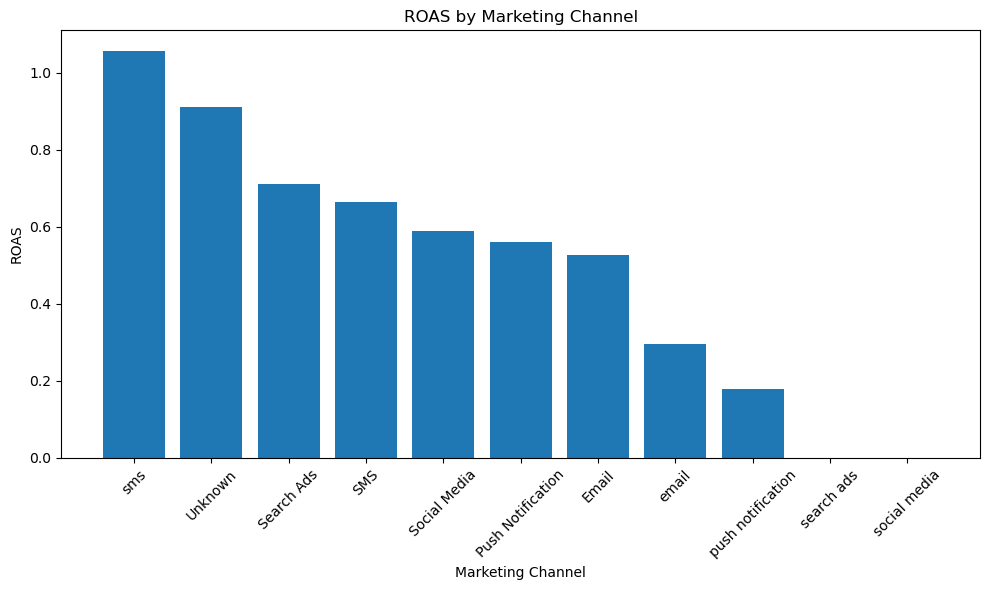

In [183]:
# ============================================================
# CELL 33: ROAS BY MARKETING CHANNEL
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    channel_analysis["campaign_channel"],
    channel_analysis["ROAS"]
)

plt.title(
    "ROAS by Marketing Channel"
)

plt.xlabel("Marketing Channel")
plt.ylabel("ROAS")

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()



 # CUSTOMER INTERACTION ANALYSIS

In [184]:
# ============================================================
# CELL 34: CUSTOMER INTERACTIONS
# ============================================================

interaction_analysis = (
    customer_interactions
    .groupby("interaction_type")
    .agg(
        interactions=(
            "interaction_id",
            "count"
        ),
        conversions=(
            "converted",
            "sum"
        ),
        avg_session_duration=(
            "session_duration_min",
            "mean"
        )
    )
    .reset_index()
)

interaction_analysis[
    "conversion_rate"
] = (
    interaction_analysis["conversions"]
    /
    interaction_analysis["interactions"]
    * 100
)

display(interaction_analysis)



,interaction_type,interactions,conversions,avg_session_duration,conversion_rate
0,Add to Cart,23925,6746,19.82,28.20
1,Login,39715,1104,20.65,2.78
2,Product View,71766,5839,20.05,8.14
3,Purchase,21928,20195,20.20,92.10
4,Search,29679,917,20.30,3.09
5,Unknown,1000,173,11.36,17.30
6,Wishlist,11987,361,21.03,3.01


 # DEVICE ANALYSIS

In [185]:
# ============================================================
# CELL 35: DEVICE PERFORMANCE
# ============================================================

device_analysis = (
    customer_interactions
    .groupby("device_type")
    .agg(
        interactions=(
            "interaction_id",
            "count"
        ),
        conversions=(
            "converted",
            "sum"
        ),
        avg_session_duration=(
            "session_duration_min",
            "mean"
        )
    )
    .reset_index()
)

device_analysis[
    "conversion_rate"
] = (
    device_analysis["conversions"]
    /
    device_analysis["interactions"]
    * 100
)

display(device_analysis)



,device_type,interactions,conversions,avg_session_duration,conversion_rate
0,Desktop,66061,11696,20.71,17.70
1,Mobile,123711,21862,20.06,17.67
2,Tablet,10228,1777,18.87,17.37


 # REPEAT CUSTOMER ANALYSIS

In [186]:
# ============================================================
# CELL 36: REPEAT CUSTOMER ANALYSIS
# ============================================================

customer_orders = (
    valid_revenue_orders
    .groupby("customer_id")
    .agg(
        total_orders=(
            "order_id",
            "nunique"
        ),
        total_revenue=(
            "calculated_order_value",
            "sum"
        )
    )
    .reset_index()
)

customer_orders["customer_type"] = np.where(
    customer_orders["total_orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

repeat_summary = (
    customer_orders[
        "customer_type"
    ]
    .value_counts()
    .reset_index()
)

repeat_summary.columns = [
    "customer_type",
    "customers"
]

repeat_summary["percentage"] = (
    repeat_summary["customers"]
    /
    repeat_summary["customers"].sum()
    * 100
)

display(repeat_summary)



,customer_type,customers,percentage
0,Repeat Customer,26062,90.60
1,One-Time Customer,2705,9.40


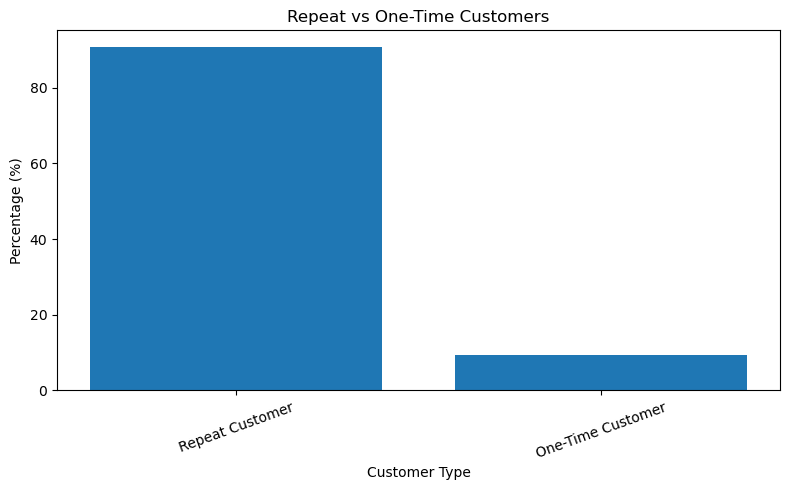

In [187]:
# ============================================================
# CELL 37: REPEAT CUSTOMER CHART
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    repeat_summary["customer_type"],
    repeat_summary["percentage"]
)

plt.title(
    "Repeat vs One-Time Customers"
)

plt.xlabel("Customer Type")
plt.ylabel("Percentage (%)")

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()



 # Q3 CATEGORY PERFORMANCE

In [188]:
# ============================================================
# CELL 38: Q3 CATEGORY PERFORMANCE
# ============================================================

q3_order_ids = (
    q3_2025["order_id"]
    .unique()
)

q3_items = order_items[
    order_items["order_id"]
    .isin(q3_order_ids)
].copy()

q3_items = q3_items.merge(
    products[
        [
            "product_id",
            "category"
        ]
    ],
    on="product_id",
    how="left"
)

q3_category = (
    q3_items
    .groupby("category")
    .agg(
        revenue=(
            "item_revenue",
            "sum"
        ),
        profit=(
            "profit",
            "sum"
        ),
        units=(
            "quantity",
            "sum"
        )
    )
    .reset_index()
)

q3_category[
    "profit_margin"
] = (
    q3_category["profit"]
    /
    q3_category["revenue"]
    * 100
)

q3_category = (
    q3_category
    .sort_values(
        "revenue",
        ascending=False
    )
)

display(q3_category)



,category,revenue,profit,units,profit_margin
2,Electronics,"880,993,617.98","297,423,892.34",25853,33.76
4,Home,"68,472,579.72","23,784,049.31",14501,34.74
6,Unknown,"26,751,872.96","5,420,631.58",1386,20.26
3,Fashion,"21,449,967.17","7,701,608.83",14425,35.90
0,Beauty,"17,385,160.93","10,467,323.10",7483,60.21
5,Sports,"11,558,188.54","3,739,558.03",6168,32.35
1,Books,"6,064,370.56","3,812,520.67",6817,62.87


 # CATEGORY REVENUE BY QUARTER

In [189]:
# ============================================================
# CELL 39: QUARTERLY CATEGORY PERFORMANCE
# ============================================================

quarterly_category = (
    order_items
    .merge(
        orders[
            [
                "order_id",
                "year",
                "quarter"
            ]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        products[
            [
                "product_id",
                "category"
            ]
        ],
        on="product_id",
        how="left"
    )
    .groupby(
        [
            "year",
            "quarter",
            "category"
        ]
    )
    .agg(
        revenue=(
            "item_revenue",
            "sum"
        ),
        profit=(
            "profit",
            "sum"
        )
    )
    .reset_index()
)

display(
    quarterly_category
    .sort_values(
        [
            "year",
            "quarter",
            "revenue"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
)



,year,quarter,category,revenue,profit
2,"2,024.00",1.00,Electronics,"827,495,087.71","263,859,361.13"
4,"2,024.00",1.00,Home,"67,213,018.42","22,768,124.17"
6,"2,024.00",1.00,Unknown,"25,382,097.62","5,154,884.68"
3,"2,024.00",1.00,Fashion,"22,556,065.15","8,555,250.04"
0,"2,024.00",1.00,Beauty,"17,056,142.15","10,343,109.98"
5,"2,024.00",1.00,Sports,"11,668,034.30","3,271,605.18"
1,"2,024.00",1.00,Books,"5,265,838.77","3,323,829.74"
9,"2,024.00",2.00,Electronics,"837,393,828.08","269,450,893.96"
11,"2,024.00",2.00,Home,"62,406,232.68","19,184,098.43"
13,"2,024.00",2.00,Unknown,"24,034,160.00","4,687,933.07"


 # DATA RECONCILIATION



 This section is retained to monitor the difference between

 source order_value and the validated calculated_order_value.



 It is a data-quality diagnostic and should not replace the

 validated revenue used in the main analysis.

In [190]:
# ============================================================
# CELL 40: REVENUE RECONCILIATION
# ============================================================

print("=" * 70)
print("REVENUE RECONCILIATION")
print("=" * 70)

total_source_order_value = (
    orders["order_value"].sum()
)

total_calculated_order_value = (
    orders["calculated_order_value"].sum()
)

total_item_revenue = (
    order_items["item_revenue"].sum()
)

total_profit = (
    order_items["profit"].sum()
)

print(
    f"Source Order Value: "
    f"₹{total_source_order_value:,.2f}"
)

print(
    f"Calculated Order Value: "
    f"₹{total_calculated_order_value:,.2f}"
)

print(
    f"Item Revenue: "
    f"₹{total_item_revenue:,.2f}"
)

print(
    f"Total Profit: "
    f"₹{total_profit:,.2f}"
)

print(
    "\nProfit / Item Revenue Ratio:",
    total_profit / total_item_revenue
)

print(
    "Item Revenue / Calculated Order Value Ratio:",
    total_item_revenue
    / total_calculated_order_value
)



REVENUE RECONCILIATION
Source Order Value: ₹393,604,298.88
Calculated Order Value: ₹7,904,103,669.66
Item Revenue: ₹7,893,619,492.42
Total Profit: ₹2,601,149,330.28

Profit / Item Revenue Ratio: 0.3295255532368639
Item Revenue / Calculated Order Value Ratio: 0.9986735779693474


 # ORDER-LEVEL RECONCILIATION

In [191]:
# ============================================================
# CELL 41: ORDER VALUE RELATIONSHIP
# ============================================================

order_check = (
    order_items
    .groupby("order_id")["item_revenue"]
    .sum()
    .reset_index()
)

order_check.rename(
    columns={
        "item_revenue":
        "item_revenue_total"
    },
    inplace=True
)

order_check = order_check.merge(
    orders[
        [
            "order_id",
            "order_value",
            "calculated_order_value",
            "shipping_fee",
            "discount_amount"
        ]
    ],
    on="order_id",
    how="inner"
)

order_check[
    "recalculated_order_value"
] = (
    order_check["item_revenue_total"]
    +
    order_check["shipping_fee"]
)

order_check[
    "difference_from_source"
] = (
    order_check["order_value"]
    -
    order_check["recalculated_order_value"]
)

order_check[
    "difference_from_calculated"
] = (
    order_check["calculated_order_value"]
    -
    order_check["recalculated_order_value"]
)

display(
    order_check.head(20)
)



,order_id,item_revenue_total,order_value,calculated_order_value,shipping_fee,discount_amount,recalculated_order_value,difference_from_source,difference_from_calculated
0,O100001,"2,227.93","1,441.17","2,265.39",37.46,189.67,"2,265.39",-824.22,0.00
1,O100002,"3,376.88",507.03,"3,461.39",84.51,508.36,"3,461.39","-2,954.36",0.00
2,O100003,"42,898.04",610.94,"43,003.03",104.99,132.32,"43,003.03","-42,392.09",0.00
3,O100004,"5,084.66","2,543.50","5,108.04",23.38,47.50,"5,108.04","-2,564.54",0.00
4,O100005,"2,691.30","3,176.87","2,744.40",53.10,222.56,"2,744.40",432.47,0.00
5,O100006,"46,479.01",880.17,"46,484.14",5.13,27.42,"46,484.14","-45,603.97",0.00
6,O100007,"45,893.10",782.31,"46,010.05",116.95,165.49,"46,010.05","-45,227.74",0.00
7,O100008,"2,593.41","4,354.21","2,679.30",85.89,543.23,"2,679.30","1,674.91",0.00
8,O100009,"43,233.38",891.59,"43,312.39",79.01,216.39,"43,312.39","-42,420.80",0.00
9,O100010,"16,620.91",537.58,"16,678.92",58.01,617.54,"16,678.92","-16,141.34",0.00


In [192]:
# ============================================================
# CELL 42: RECONCILIATION SUMMARY
# ============================================================

print(
    "Orders checked:",
    len(order_check)
)

print(
    "Source order_value mismatches:",
    (
        order_check[
            "difference_from_source"
        ].abs() > 0.01
    ).sum()
)

print(
    "Calculated order value mismatches:",
    (
        order_check[
            "difference_from_calculated"
        ].abs() > 0.01
    ).sum()
)



Orders checked: 149209
Source order_value mismatches: 148211
Calculated order value mismatches: 0


 # REVENUE / AOV VALIDATION

In [193]:
# ============================================================
# CELL 43: FINAL REVENUE AND AOV CHECK
# ============================================================

print("=" * 70)
print("FINAL REVENUE AND AOV CHECK")
print("=" * 70)

valid_orders = orders[
    orders["calculated_order_value"].notna()
].copy()

print(
    "Total orders:",
    len(orders)
)

print(
    "Missing calculated_order_value:",
    orders[
        "calculated_order_value"
    ].isna().sum()
)

print(
    "Orders with valid revenue:",
    len(valid_orders)
)

print(
    "Validated Revenue:",
    f"₹{valid_orders['calculated_order_value'].sum():,.2f}"
)

print(
    "Validated AOV:",
    f"₹{valid_orders['calculated_order_value'].mean():,.2f}"
)

print(
    "AOV using mean:",
    f"₹{valid_orders['calculated_order_value'].mean():,.2f}"
)



FINAL REVENUE AND AOV CHECK
Total orders: 149500
Missing calculated_order_value: 291
Orders with valid revenue: 149209
Validated Revenue: ₹7,904,103,669.66
Validated AOV: ₹52,973.37
AOV using mean: ₹52,973.37


 # FINAL BUSINESS INSIGHTS

In [194]:
# ============================================================
# CELL 44: BUSINESS INSIGHTS SUMMARY
# ============================================================

print("=" * 70)
print("SHOPSPHERE BUSINESS ANALYSIS SUMMARY")
print("=" * 70)

print(
    f"\nTotal Revenue: "
    f"₹{total_revenue:,.2f}"
)

print(
    f"Total Orders: "
    f"{total_orders:,}"
)

print(
    f"Total Customers: "
    f"{total_customers:,}"
)

print(
    f"Average Order Value: "
    f"₹{average_order_value:,.2f}"
)

print(
    f"Total Product Revenue: "
    f"₹{total_item_revenue:,.2f}"
)

print(
    f"Total Profit: "
    f"₹{total_profit:,.2f}"
)

print(
    f"Profit Margin: "
    f"{profit_margin:.2f}%"
)

print(
    f"Cancellation Rate: "
    f"{cancellation_rate:.2f}%"
)


# Best Category
best_category = (
    category_analysis
    .iloc[0]
)

print(
    f"\nHighest Revenue Category: "
    f"{best_category['category']}"
)

print(
    f"Category Revenue: "
    f"₹{best_category['revenue']:,.2f}"
)


# Best Customer Segment
best_segment = (
    segment_revenue
    .iloc[0]
)

print(
    f"\nHighest Revenue Customer Segment: "
    f"{best_segment['customer_segment']}"
)

print(
    f"Segment Revenue: "
    f"₹{best_segment['revenue']:,.2f}"
)


# Best Marketing Channel
valid_channels = (
    channel_analysis
    .dropna(
        subset=["ROAS"]
    )
)

if len(valid_channels) > 0:

    best_channel = (
        valid_channels
        .iloc[0]
    )

    print(
        f"\nHighest ROAS Marketing Channel: "
        f"{best_channel['campaign_channel']}"
    )

    print(
        f"ROAS: "
        f"{best_channel['ROAS']:.2f}"
    )


# Top Product
best_product = (
    product_analysis
    .iloc[0]
)

print(
    f"\nHighest Revenue Product: "
    f"{best_product['product_name']}"
)

print(
    f"Product Revenue: "
    f"₹{best_product['revenue']:,.2f}"
)


# Best Region
best_region = (
    region_analysis
    .iloc[0]
)

print(
    f"\nHighest Revenue Region: "
    f"{best_region['shipping_region']}"
)

print(
    f"Region Revenue: "
    f"₹{best_region['revenue']:,.2f}"
)


# Repeat Customer Rate
repeat_customer_pct = repeat_summary.loc[
    repeat_summary["customer_type"]
    == "Repeat Customer",
    "percentage"
]

if len(repeat_customer_pct) > 0:

    print(
        f"\nRepeat Customer Rate: "
        f"{repeat_customer_pct.iloc[0]:.2f}%"
    )

print("\n" + "=" * 70)
print(
    "EDA AND BUSINESS ANALYSIS COMPLETED"
)
print("=" * 70)



SHOPSPHERE BUSINESS ANALYSIS SUMMARY

Total Revenue: ₹7,904,103,669.66
Total Orders: 149,500
Total Customers: 30,000
Average Order Value: ₹52,973.37
Total Product Revenue: ₹7,893,619,492.42
Total Profit: ₹2,601,149,330.28
Profit Margin: 32.95%
Cancellation Rate: 7.11%

Highest Revenue Category: Electronics
Category Revenue: ₹6,711,804,098.99

Highest Revenue Customer Segment: Premium
Segment Revenue: ₹3,173,550,166.90

Highest ROAS Marketing Channel: sms
ROAS: 1.06

Highest Revenue Product: Orbit Electronics Accessories 769
Product Revenue: ₹234,297,040.00

Highest Revenue Region: West
Region Revenue: ₹2,684,049,942.89

Repeat Customer Rate: 90.60%

EDA AND BUSINESS ANALYSIS COMPLETED


 # END OF NOTEBOOK